In [1]:
import pandas as pd
data=pd.read_csv(r'C:\Users\asjas\OneDrive\Documents\Docker projects\churn-retention-forecasting\data\raw\customer_churn_dataset-training-master.csv')
data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [2]:
data.dropna(how='all', inplace=True)
data

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [3]:
print(data.duplicated().sum())

0


In [4]:
data.drop('CustomerID', axis=1, inplace=True)

Feature encoding (creating new columns) - skipping for now

One-hot encoding all the categorical columns

In [5]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. Define categorical columns
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

# 2. Fit encoder on these columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

one_hot_encoded = encoder.fit_transform(data[categorical_cols])

# 3. Turn encoded array into DataFrame
one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=data.index   # keep same index so concat is safe
)

# 4. Drop original categorical columns and concat encoded ones
data_encoded = pd.concat(
    [data.drop(categorical_cols, axis=1), one_hot_df],
    axis=1
)


In [6]:
data_encoded

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Female,Gender_Male,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [7]:
# Select only numerical columns (excluding the target 'Churn' if it's there)
numerical_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 
                  'Payment Delay', 'Total Spend', 'Last Interaction']

# Calculate skewness
skew_values = data[numerical_cols].skew().sort_values(ascending=False)

print("Skewness Coefficients:")
print(skew_values)


Skewness Coefficients:
Support Calls       0.666809
Payment Delay       0.267407
Last Interaction    0.176774
Age                 0.162016
Usage Frequency    -0.043473
Tenure             -0.061402
Total Spend        -0.457174
dtype: float64


How to Interpret the Numbers:

-0.5 to 0.5: Symmetric (Normal enough). Action: No transformation needed. MinMax Scaling is fine.

-1 to -0.5 OR 0.5 to 1: Moderately Skewed. Action: Consider Log Transform, but often robust enough to ignore.

< -1 OR > 1: Highly Skewed. Action: Must Fix (Log Transform or Box-Cox).

<Axes: xlabel='Support Calls'>

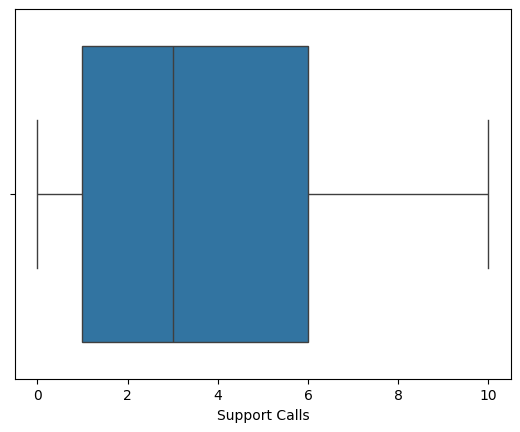

In [9]:
import seaborn as sns
sns.boxplot(x=data['Support Calls'])